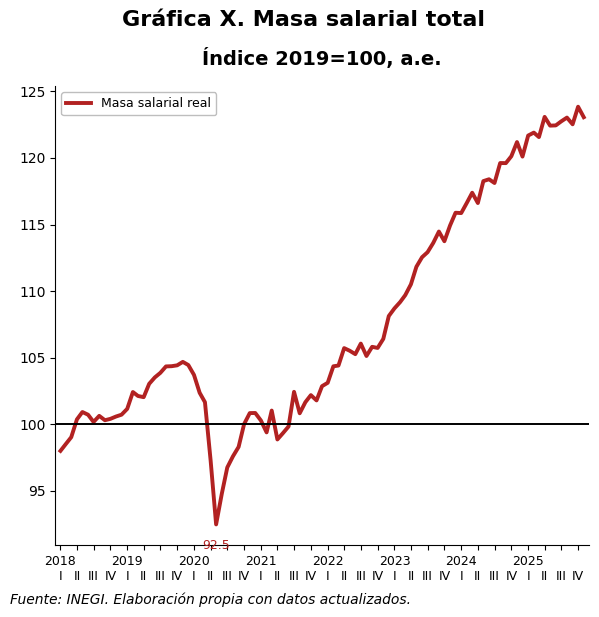

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata

# ============================================================
# CONFIG
# ============================================================
PATH = "raw/remuneraciones.csv"

RED   = "#b22222"
BLACK = "#000000"

# ============================================================
# 1) LECTOR ROBUSTO (formato INEGI: años + meses en "Periodo")
# ============================================================
MONTH_MAP = {
    "enero": 1, "febrero": 2, "marzo": 3, "abril": 4, "mayo": 5, "junio": 6,
    "julio": 7, "agosto": 8, "septiembre": 9, "setiembre": 9, "octubre": 10,
    "noviembre": 11, "diciembre": 12
}

def _norm(s: str) -> str:
    # quita acentos, lower, strip
    s = str(s).strip().lower()
    s = "".join(c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn")
    return s

def read_inegi_periodo_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    # asegura columnas esperadas
    if "Periodo" not in df.columns:
        raise ValueError(f"No encuentro columna 'Periodo'. Columnas: {list(df.columns)}")
    if "Índice" not in df.columns and "Indice" in df.columns:
        df = df.rename(columns={"Indice":"Índice"})
    if "Índice" not in df.columns:
        raise ValueError(f"No encuentro columna 'Índice'. Columnas: {list(df.columns)}")

    # limpia periodo
    df["Periodo_raw"] = df["Periodo"]
    df["Periodo"] = df["Periodo"].astype(str).str.strip()

    # quita filas tipo "Fuente"
    df = df[~df["Periodo"].str.lower().str.startswith("fuente")].copy()

    # ---- año: conversión segura (NO truena con 'Enero')
    df["year"] = pd.to_numeric(df["Periodo"], errors="coerce")  # 2018, 2019, etc; meses -> NaN
    df["year"] = df["year"].ffill()

    # ---- mes (normalizando acentos)
    df["mon_key"] = df["Periodo"].map(_norm)
    df["month"] = df["mon_key"].map(MONTH_MAP)

    # filas válidas: mes reconocido + índice numérico
    df["Índice"] = pd.to_numeric(df["Índice"], errors="coerce")
    df = df[df["month"].notna() & df["Índice"].notna() & df["year"].notna()].copy()

    # fecha mensual (primer día)
    df["date"] = pd.to_datetime(
        dict(year=df["year"].astype(int), month=df["month"].astype(int), day=1)
    )

    df = df.sort_values("date").reset_index(drop=True)
    return df[["date","Índice"]]

df = read_inegi_periodo_csv(PATH)

# ============================================================
# 2) GRÁFICA ESTILO (como tu ejemplo)
# ============================================================
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

ax.plot(df["date"], df["Índice"], color=RED, lw=2.8, label="Masa salarial real")
ax.axhline(100, color=BLACK, lw=1.4)

# ticks por trimestre (I, II, III, IV), mostrando año al inicio de cada año
tmp = df.copy()
tmp["y"] = tmp["date"].dt.year
tmp["q"] = tmp["date"].dt.quarter
tmp["yq"] = tmp["y"].astype(str) + "Q" + tmp["q"].astype(str)

ticks = tmp.groupby("yq")["date"].min()
years = ticks.dt.year.values
quarters = ticks.dt.quarter.map({1:"I",2:"II",3:"III",4:"IV"}).values

labels = []
prev = None
for yy, qq in zip(years, quarters):
    if prev != yy:
        labels.append(f"{yy}\n{qq}")
    else:
        labels.append(f"\n{qq}")
    prev = yy

ax.set_xticks(ticks.values)
ax.set_xticklabels(labels, fontsize=9)

ax.set_title(
    "Índice 2019=100, a.e.",
    loc="center", fontsize=14, fontweight="bold", pad=15
    )

leg = ax.legend(loc="upper left", frameon=True, fontsize=9)
leg.get_frame().set_alpha(0.85)
leg.get_frame().set_edgecolor("0.7")

# anota el mínimo
i_min = df["Índice"].idxmin()
min_row = df.loc[i_min]
ax.annotate(
    f"{min_row['Índice']:.1f}",
    xy=(min_row["date"], min_row["Índice"]),
    xytext=(0, -18),
    textcoords="offset points",
    ha="center",
    fontsize=9,
    color=RED
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
ax.set_ylabel("")
ax.margins(x=0.01)
fig.suptitle(
    "Gráfica X. Masa salarial total", 
    fontsize=16, fontweight="bold", y=0.98
)
fig.text(
    0.01, -0.01,
    "Fuente: INEGI. Elaboración propia con datos actualizados.",
    ha="left", fontsize=10, style="italic"
)

plt.tight_layout()
plt.show()


/var/folders/5x/v_n3jdfd003f7mqj3m9j1k0h0000gn/T/ipykernel_77634/816825119.py:270: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 1])


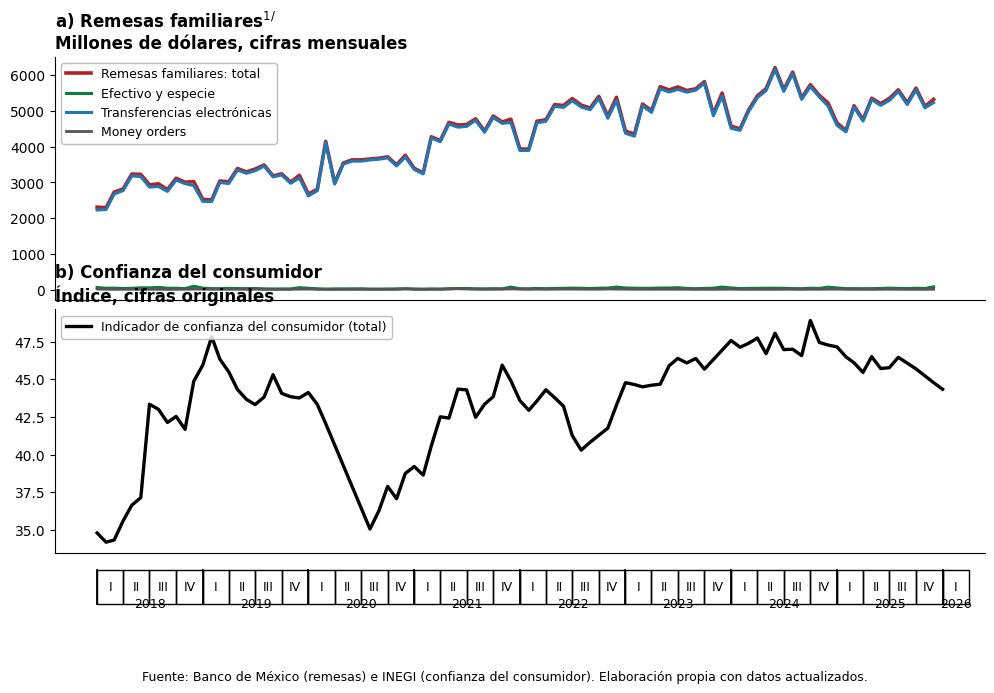

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import unicodedata

# ============================================================
# CONFIG
# ============================================================
PATH_REMESAS = "raw/remesas.xlsx"
PATH_ICC     = "raw/Indicador_de_confianza_del_consumidor.xlsx"

START_DATE = "2018-01-01"   # recorte (ajusta si quieres)

RED   = "#b22222"
BLUE  = "#1f77b4"
GREEN = "#0b7d3e"
BLACK = "#000000"
GRAY  = "#555555"

Q_ROMAN = {1:"I", 2:"II", 3:"III", 4:"IV"}

# ============================================================
# Helpers
# ============================================================
def _norm(s: str) -> str:
    s = str(s).strip().lower()
    s = "".join(c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn")
    return s

MONTH_MAP = {
    "enero": 1, "febrero": 2, "marzo": 3, "abril": 4, "mayo": 5, "junio": 6,
    "julio": 7, "agosto": 8, "septiembre": 9, "setiembre": 9, "octubre": 10,
    "noviembre": 11, "diciembre": 12,
    "ene": 1, "feb": 2, "mar": 3, "abr": 4, "may": 5, "jun": 6,
    "jul": 7, "ago": 8, "sep": 9, "oct": 10, "nov": 11, "dic": 12
}

def add_quarter_boxes(ax_box, dates):
    """Banda inferior con cajitas por trimestre + años."""
    ax_box.set_ylim(0, 1)
    ax_box.set_yticks([])
    for s in ["top", "right", "left", "bottom"]:
        ax_box.spines[s].set_visible(False)
    ax_box.set_xticks([])

    d = pd.Series(pd.to_datetime(dates, errors="coerce")).dropna().sort_values()
    if d.empty:
        return

    tmp = pd.DataFrame({"date": d})
    tmp["y"] = tmp["date"].dt.year
    tmp["q"] = tmp["date"].dt.quarter
    tmp["yq"] = tmp["y"].astype(str) + "Q" + tmp["q"].astype(str)

    q_start = tmp.groupby("yq")["date"].min().sort_values()
    q_year  = q_start.dt.year.values
    q_quart = q_start.dt.quarter.values
    nq = len(q_start)

    q_left = q_start.values
    q_right = np.empty_like(q_left, dtype="datetime64[ns]")
    q_right[:-1] = q_left[1:]
    q_right[-1] = (pd.Timestamp(q_left[-1]) + pd.DateOffset(months=3)).to_datetime64()

    # cajitas
    for i in range(nq):
        x0 = pd.Timestamp(q_left[i])
        x1 = pd.Timestamp(q_right[i])
        w = x1 - x0

        rect = patches.Rectangle(
            (x0, 0.15), w, 0.70,
            fill=False, edgecolor="black", linewidth=1.0
        )
        ax_box.add_patch(rect)

        ax_box.text(
            x0 + w/2, 0.50, Q_ROMAN[int(q_quart[i])],
            ha="center", va="center", fontsize=9
        )

    # separadores de año (un poco más gruesos)
    for i in range(nq):
        if i == 0 or q_year[i] != q_year[i-1]:
            ax_box.axvline(pd.Timestamp(q_left[i]), ymin=0.15, ymax=0.85, color="black", lw=1.3)

    # años centrados por bloque
    for yy in sorted(set(q_year)):
        idx = np.where(q_year == yy)[0]
        if len(idx) == 0:
            continue
        xL = pd.Timestamp(q_left[idx[0]])
        xR = pd.Timestamp(q_right[idx[-1]])
        xM = xL + (xR - xL)/2
        ax_box.text(xM, 0.02, str(yy), ha="center", va="bottom", fontsize=9)


# ============================================================
# 1) REMESAS (Banxico) - lector correcto usando CÓDIGO+TÍTULO+UNIDAD
#    para quedarnos con "Millones de Dólares"
# ============================================================
def read_banxico_remesas_excel(path: str) -> pd.DataFrame:
    raw = pd.read_excel(path, sheet_name=0, header=None)

    def find_row(label):
        idx = raw.index[raw[0].astype(str).str.strip().eq(label)]
        if len(idx) == 0:
            raise ValueError(f"No encontré fila '{label}' en remesas.xlsx.")
        return int(idx[0])

    r_title = find_row("Título")
    r_unit  = find_row("Unidad")
    r_date  = find_row("Fecha")

    titles = raw.loc[r_title, 1:].tolist()
    units  = raw.loc[r_unit, 1:].tolist()
    codes  = raw.loc[r_date, 1:].tolist()

    # datos desde la fila posterior a "Fecha"
    dat = raw.loc[r_date+1:, :].copy()
    dat = dat.rename(columns={0: "date"})
    dat["date"] = pd.to_datetime(dat["date"], errors="coerce")
    dat = dat.dropna(subset=["date"])

    # nos quedamos con date + columnas de códigos
    dat = dat.iloc[:, :len(codes)+1]
    dat.columns = ["date"] + codes

    meta = pd.DataFrame({"code": codes, "title": titles, "unit": units})
    meta["title"] = meta["title"].astype(str).str.strip()
    meta["unit"]  = meta["unit"].astype(str).str.strip()

    def get_series(title_exact: str, unit_exact: str = "Millones de Dólares"):
        m = meta[(meta["title"] == title_exact) & (meta["unit"] == unit_exact)]
        if m.empty:
            raise ValueError(f"No encontré '{title_exact}' con unidad '{unit_exact}'.")
        code = m.iloc[0]["code"]
        s = dat[["date", code]].rename(columns={code: title_exact})
        s[title_exact] = pd.to_numeric(s[title_exact], errors="coerce")
        return s

    out = pd.DataFrame({"date": dat["date"]})

    # --- las que pediste
    s_total = get_series("Remesas Familiares, Total")
    s_efec  = get_series("Remesas Familiares, Efectivo y Especie")
    s_elec  = get_series("Remesas Familiares, Transferencias Electrónicas")

    # --- extra que pediste en el mensaje anterior: Money Orders (si NO la quieres, borra estas 2 líneas)
    s_mo    = get_series("Remesas Familiares, Money Orders")

    out = out.merge(s_total, on="date", how="left")
    out = out.merge(s_efec,  on="date", how="left")
    out = out.merge(s_elec,  on="date", how="left")
    out = out.merge(s_mo,    on="date", how="left")

    out = out.rename(columns={
        "Remesas Familiares, Total": "rem_total",
        "Remesas Familiares, Efectivo y Especie": "rem_efec",
        "Remesas Familiares, Transferencias Electrónicas": "rem_elec",
        "Remesas Familiares, Money Orders": "rem_money_orders",
    })

    out = out.sort_values("date").reset_index(drop=True)
    return out


# ============================================================
# 2) ICC (INEGI) - lector del sheet "Total"
# ============================================================
def read_icc_inegi_excel(path: str, sheet_name="Total") -> pd.DataFrame:
    raw = pd.read_excel(path, sheet_name=sheet_name, header=None)

    idx = raw.index[raw[0].astype(str).str.strip().eq("Periodo")]
    if len(idx) == 0:
        raise ValueError("No encontré la fila 'Periodo' en el ICC.")
    i0 = int(idx[0])

    mat = raw.loc[i0+1:, [0,1]].copy()
    mat.columns = ["Periodo", "ICC"]

    mat["Periodo"] = mat["Periodo"].astype(str).str.strip()

    # año en filas tipo "2001", "2002"...
    mat["year"] = pd.to_numeric(mat["Periodo"], errors="coerce").ffill()

    # mes en filas tipo "Enero", "Febrero"...
    mat["mon_key"] = mat["Periodo"].map(_norm)
    mat["month"] = mat["mon_key"].map(MONTH_MAP)

    mat["ICC"] = pd.to_numeric(mat["ICC"], errors="coerce")
    mat = mat[mat["month"].notna() & mat["ICC"].notna() & mat["year"].notna()].copy()

    mat["date"] = pd.to_datetime(dict(
        year=mat["year"].astype(int),
        month=mat["month"].astype(int),
        day=1
    ))

    out = mat[["date","ICC"]].sort_values("date").reset_index(drop=True)
    return out


# ============================================================
# 3) CARGA + RECORTE
# ============================================================
rem = read_banxico_remesas_excel(PATH_REMESAS)
icc = read_icc_inegi_excel(PATH_ICC, sheet_name="Total")

start = pd.to_datetime(START_DATE)
rem = rem[rem["date"] >= start].copy()
icc = icc[icc["date"] >= start].copy()


# ============================================================
# 4) FIGURA 2 PANELES + CAJITAS
# ============================================================
fig = plt.figure(figsize=(12.0, 7.2))
gs = fig.add_gridspec(nrows=3, ncols=1, height_ratios=[10, 10, 2], hspace=0.05)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
axb = fig.add_subplot(gs[2, 0], sharex=ax1)

# ---------------- Panel (a): Remesas ----------------
ax1.plot(rem["date"], rem["rem_total"], color=RED,   lw=2.6, label="Remesas familiares: total")
ax1.plot(rem["date"], rem["rem_efec"],  color=GREEN, lw=2.2, label="Efectivo y especie")
ax1.plot(rem["date"], rem["rem_elec"],  color=BLUE,  lw=2.2, label="Transferencias electrónicas")
ax1.plot(rem["date"], rem["rem_money_orders"], color=GRAY, lw=2.0, label="Money orders")  # si no la quieres, bórrala

ax1.set_title("a) Remesas familiares$^{1/}$\nMillones de dólares, cifras mensuales", loc="left", fontsize=12, weight="bold")

leg1 = ax1.legend(loc="upper left", frameon=True, fontsize=9)
leg1.get_frame().set_alpha(0.85)
leg1.get_frame().set_edgecolor("0.7")

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(False)
ax1.set_ylabel("")
ax1.tick_params(axis="x", labelbottom=False)

# ---------------- Panel (b): Confianza del consumidor ----------------
ax2.plot(icc["date"], icc["ICC"], color=BLACK, lw=2.4, label="Indicador de confianza del consumidor (total)")

ax2.set_title("b) Confianza del consumidor\nÍndice, cifras originales", loc="left", fontsize=12, weight="bold")

leg2 = ax2.legend(loc="upper left", frameon=True, fontsize=9)
leg2.get_frame().set_alpha(0.85)
leg2.get_frame().set_edgecolor("0.7")

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(False)
ax2.set_ylabel("")
ax2.tick_params(axis="x", labelbottom=False)

# ---------------- Cajitas (trimestres) ----------------
all_dates = pd.concat([rem["date"], icc["date"]], ignore_index=True)
add_quarter_boxes(axb, all_dates)

# ---------------- Nota ----------------
fig.text(
    0.5, 0.01,
    "Fuente: Banco de México (remesas) e INEGI (confianza del consumidor). Elaboración propia con datos actualizados.",
    ha="center", va="bottom", fontsize=9
)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata

# ============================================================
# CONFIG
# ============================================================
PATH_REMESAS = "raw/remesas.xlsx"
PATH_ICC     = "raw/Indicador_de_confianza_del_consumidor.xlsx"

START_DATE = "2018-01-01"
BASE_YEAR  = 2019

# Colores (tipo Banxico)
RED   = "#b22222"
BLUE  = "#1f77b4"
GREEN = "#0b7d3e"
PURP  = "#6a2ca0"   # morado (para ICC si quieres distinguir)
BLACK = "#000000"

# ============================================================
# HELPERS
# ============================================================
def _norm(s: str) -> str:
    s = str(s).strip().lower()
    s = "".join(c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn")
    return s

MONTH_MAP = {
    "enero": 1, "febrero": 2, "marzo": 3, "abril": 4, "mayo": 5, "junio": 6,
    "julio": 7, "agosto": 8, "septiembre": 9, "setiembre": 9, "octubre": 10,
    "noviembre": 11, "diciembre": 12,
    "ene": 1, "feb": 2, "mar": 3, "abr": 4, "may": 5, "jun": 6,
    "jul": 7, "ago": 8, "sep": 9, "oct": 10, "nov": 11, "dic": 12
}


def style_banxico_axis(ax, yline100=True):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    if yline100:
        ax.axhline(100, color=BLACK, lw=2.2)  # gruesa como Banxico
    ax.tick_params(axis="both", labelsize=9)

def annotate_minima(ax, df, cols, colors, date_col="date",
                    window_start="2020-01-01", window_end="2020-12-31",
                    y_text_pad=0.6):
    """
    Anota mínimos (tipo 78.0, 76.4, 71.9) cerca de 2020 como en el ejemplo.
    """
    d = df.copy()
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    w = d[(d[date_col] >= pd.to_datetime(window_start)) & (d[date_col] <= pd.to_datetime(window_end))].copy()
    if w.empty:
        return

    # Pone textos “apilados” (uno debajo del otro) cerca de la fecha del mínimo
    # Tomamos un x común: el mínimo más temprano para que se vea como el ejemplo
    mins = []
    for c, col in zip(cols, colors):
        s = pd.to_numeric(w[c], errors="coerce")
        if s.notna().sum() == 0:
            continue
        i = s.idxmin()
        x = w.loc[i, date_col]
        y = w.loc[i, c]
        mins.append((x, y, c, col))

    if not mins:
        return

    # x base: el mínimo "más a la izquierda"
    x0 = sorted(mins, key=lambda t: t[0])[0][0]

    # ordena por y (para apilar bonito)
    mins_sorted = sorted(mins, key=lambda t: t[1], reverse=True)
    y0 = mins_sorted[0][1]

    for k, (x, y, cname, col) in enumerate(mins_sorted):
        ax.text(x0, y0 - k*y_text_pad, f"{y:.1f}", color=col, fontsize=9, ha="left", va="center")

# ============================================================
# 1) REMESAS (Banxico) - lector robusto por Título + Unidad
# ============================================================
def read_banxico_remesas_excel(path: str) -> pd.DataFrame:
    raw = pd.read_excel(path, sheet_name=0, header=None)

    def find_row(label):
        idx = raw.index[raw[0].astype(str).str.strip().eq(label)]
        if len(idx) == 0:
            raise ValueError(f"No encontré fila '{label}' en remesas.xlsx.")
        return int(idx[0])

    r_title = find_row("Título")
    r_unit  = find_row("Unidad")
    r_date  = find_row("Fecha")

    titles = raw.loc[r_title, 1:].tolist()
    units  = raw.loc[r_unit, 1:].tolist()
    codes  = raw.loc[r_date, 1:].tolist()

    dat = raw.loc[r_date+1:, :].copy()
    dat = dat.rename(columns={0: "date"})
    dat["date"] = pd.to_datetime(dat["date"], errors="coerce")
    dat = dat.dropna(subset=["date"])

    dat = dat.iloc[:, :len(codes)+1]
    dat.columns = ["date"] + codes

    meta = pd.DataFrame({"code": codes, "title": titles, "unit": units})
    meta["title"] = meta["title"].astype(str).str.strip()
    meta["unit"]  = meta["unit"].astype(str).str.strip()

    def get_series(title_exact: str, unit_exact: str = "Millones de Dólares"):
        m = meta[(meta["title"] == title_exact) & (meta["unit"] == unit_exact)]
        if m.empty:
            # fallback: match normalizado
            tt = _norm(title_exact)
            mm = meta[(meta["title"].map(_norm) == tt) & (meta["unit"].map(_norm) == _norm(unit_exact))]
            if mm.empty:
                raise ValueError(f"No encontré '{title_exact}' con unidad '{unit_exact}'.")
            code = mm.iloc[0]["code"]
        else:
            code = m.iloc[0]["code"]

        s = dat[["date", code]].rename(columns={code: title_exact})
        s[title_exact] = pd.to_numeric(s[title_exact], errors="coerce")
        return s

    out = pd.DataFrame({"date": dat["date"]})
    out = out.merge(get_series("Remesas Familiares, Total"), on="date", how="left")
    out = out.merge(get_series("Remesas Familiares, Efectivo y Especie"), on="date", how="left")
    out = out.merge(get_series("Remesas Familiares, Transferencias Electrónicas"), on="date", how="left")
    out = out.merge(get_series("Remesas Familiares, Money Orders"), on="date", how="left")

    out = out.rename(columns={
        "Remesas Familiares, Total": "total",
        "Remesas Familiares, Efectivo y Especie": "efectivo_especie",
        "Remesas Familiares, Transferencias Electrónicas": "transfer_elec",
        "Remesas Familiares, Money Orders": "money_orders"
    })

    return out.sort_values("date").reset_index(drop=True)

# ============================================================
# 2) ICC (INEGI) - lector matriz (sheet "Total")
# ============================================================
def read_icc_inegi_excel(path: str, sheet_name="Total") -> pd.DataFrame:
    raw = pd.read_excel(path, sheet_name=sheet_name, header=None)

    idx = raw.index[raw[0].astype(str).str.strip().eq("Periodo")]
    if len(idx) == 0:
        raise ValueError("No encontré la fila 'Periodo' en el ICC.")
    i0 = int(idx[0])

    mat = raw.loc[i0+1:, [0,1]].copy()
    mat.columns = ["Periodo", "ICC"]

    mat["Periodo"] = mat["Periodo"].astype(str).str.strip()
    mat["year"] = pd.to_numeric(mat["Periodo"], errors="coerce").ffill()
    mat["mon_key"] = mat["Periodo"].map(_norm)
    mat["month"] = mat["mon_key"].map(MONTH_MAP)

    mat["ICC"] = pd.to_numeric(mat["ICC"], errors="coerce")
    mat = mat[mat["month"].notna() & mat["ICC"].notna() & mat["year"].notna()].copy()

    mat["date"] = pd.to_datetime(dict(
        year=mat["year"].astype(int),
        month=mat["month"].astype(int),
        day=1
    ))

    return mat[["date","ICC"]].sort_values("date").reset_index(drop=True)

# ============================================================
# 3) CARGAR + RECORTAR + REBASE A ÍNDICE 2019=100
# ============================================================
rem = read_banxico_remesas_excel(PATH_REMESAS)
icc = read_icc_inegi_excel(PATH_ICC, sheet_name="Total")

start = pd.to_datetime(START_DATE)
rem = rem[rem["date"] >= start].copy()
icc = icc[icc["date"] >= start].copy()



# ============================================================
# RECORTE FINAL (garantiza 2018+)
# ============================================================
START_DATE = "2018-01-01"
start = pd.to_datetime(START_DATE)

rem_idx = rem_idx[rem_idx["date"] >= start].copy()
icc_idx = icc_idx[icc_idx["date"] >= start].copy()

# --- CAP de picos SOLO para graficar (no modifica rem_idx original si copias)
rem_plot = rem_idx.copy()

# recorta "efectivo_especie" para que no aplaste al total
cap = rem_plot["efectivo_especie"].quantile(0.99)   # prueba 0.98 si sigue mal
floor = rem_plot["efectivo_especie"].quantile(0.01)

rem_plot["efectivo_especie"] = rem_plot["efectivo_especie"].clip(lower=floor, upper=cap)

# ============================================================
# LIMITES X + TICKS ANUALES (sin 1970)
# ============================================================
x_min = start
x_max = max(rem_idx["date"].max(), icc_idx["date"].max())

for ax in (ax1, ax2):
    ax.set_xlim(x_min, x_max)

    years = pd.date_range(x_min, x_max, freq="YS")  # inicio de cada año
    ax.set_xticks(years)
    ax.set_xticklabels([d.year for d in years], fontsize=9)

# ============================================================
# 4) FIGURA 2 PANELES (como tu ejemplo)
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.2, 4.9), sharex=True)

# ---------- Título general (arriba) ----------
fig.suptitle("Gráfica. Indicadores (formato Banxico)", fontsize=11, y=0.98, fontweight="bold")



# ---------- Panel (a): Remesas ----------
ax1.plot(rem_plot["date"], rem_plot["total"],            color=RED,   lw=2.8, label="Total", zorder=3)
ax1.plot(rem_plot["date"], rem_plot["transfer_elec"],    color=BLUE,  lw=2.6, label="Transferencias electrónicas", zorder=2)
ax1.plot(rem_plot["date"], rem_plot["efectivo_especie"], color=GREEN, lw=2.2, label="Efectivo y especie", zorder=1)

ax1.set_title("a) Remesas familiares y sus componentes\nÍndice 2019=100, a.e.",
              fontsize=10.5, fontweight="bold", pad=10)

style_banxico_axis(ax1, yline100=True)
ax1.legend(loc="upper left", frameon=False, fontsize=9)

# anotar mínimos (2020)
annotate_minima(
    ax1, rem_idx,
    cols=["total","transfer_elec","efectivo_especie","money_orders"],
    colors=[RED, BLUE, GREEN, BLACK],
    window_start="2020-01-01", window_end="2020-12-31",
    y_text_pad=0.7
)

# ---------- Panel (b): Confianza del consumidor ----------
ax2.plot(icc_idx["date"], icc_idx["ICC"], color=PURP, lw=2.6, label="ICC (Total)")
ax2.set_title("b) Confianza del consumidor\nÍndice 2019=100, a.e.",
              fontsize=10.5, fontweight="bold", pad=10)

style_banxico_axis(ax2, yline100=True)
ax2.legend(loc="upper left", frameon=False, fontsize=9)

annotate_minima(
    ax2, icc_idx,
    cols=["ICC"],
    colors=[PURP],
    window_start="2020-01-01", window_end="2020-12-31",
    y_text_pad=0.7
)

# ---------- Eje X: ticks anuales (como tu ejemplo) ----------
for ax in (ax1, ax2):
    ax.set_xlim(pd.to_datetime(START_DATE), max(rem_idx["date"].max(), icc_idx["date"].max()))
    # ticks cada año
    years = pd.date_range(ax.get_xlim()[0], ax.get_xlim()[1], freq="YS")
    ax.set_xticks(years)
    ax.set_xticklabels([d.year for d in years], fontsize=9)

# ---------- Ajustes de rangos Y (parecido Banxico: apretado) ----------
def tight_ylim(ax, pad=0.03):
    y0, y1 = ax.get_ylim()
    rng = y1 - y0
    ax.set_ylim(y0 - pad*rng, y1 + pad*rng)

tight_ylim(ax1, pad=0.04)
tight_ylim(ax2, pad=0.04)

# ---------- Nota al pie centrada ----------
fig.text(
    0.5, 0.02,
    "Fuente: Banco de México (remesas) e INEGI (confianza del consumidor). Elaboración propia con datos actualizados.",
    ha="center", va="bottom", fontsize=9
)

plt.tight_layout(rect=[0, 0.05, 1, 0.92])
plt.show()


NameError: name 'rem_idx' is not defined

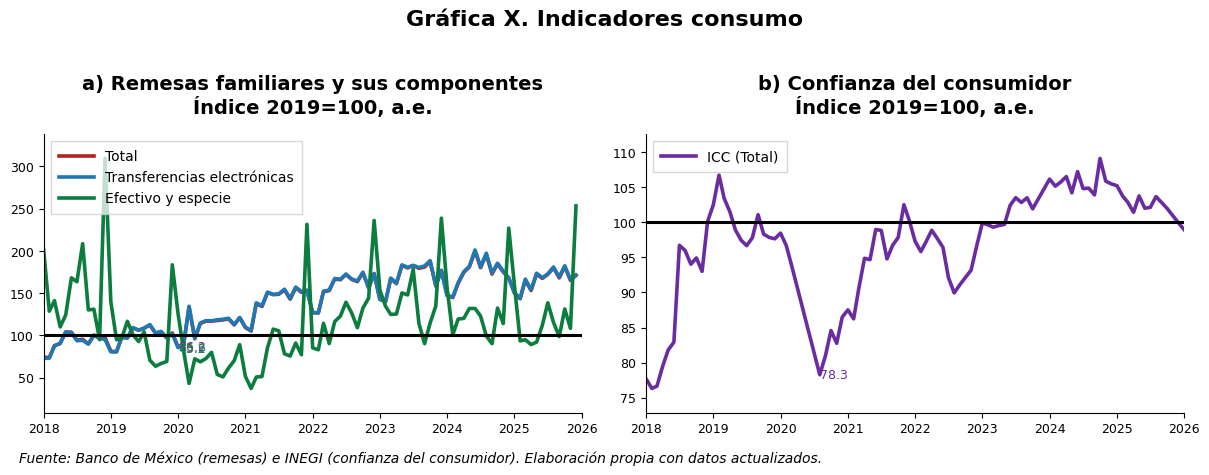

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata

# ============================================================
# CONFIG
# ============================================================
PATH_REMESAS = "raw/remesas.xlsx"
PATH_ICC     = "raw/Indicador_de_confianza_del_consumidor.xlsx"

START_DATE = "2018-01-01"
BASE_YEAR  = 2019

# Colores Banxico-like
RED   = "#b22222"
BLUE  = "#1f77b4"
GREEN = "#0b7d3e"
PURP  = "#6a2ca0"
BLACK = "#000000"

# ============================================================
# HELPERS
# ============================================================
def _norm(s: str) -> str:
    s = str(s).strip().lower()
    s = "".join(c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn")
    return s

MONTH_MAP = {
    "enero": 1, "febrero": 2, "marzo": 3, "abril": 4, "mayo": 5, "junio": 6,
    "julio": 7, "agosto": 8, "septiembre": 9, "setiembre": 9, "octubre": 10,
    "noviembre": 11, "diciembre": 12,
    "ene": 1, "feb": 2, "mar": 3, "abr": 4, "may": 5, "jun": 6,
    "jul": 7, "ago": 8, "sep": 9, "oct": 10, "nov": 11, "dic": 12
}

def style_banxico_axis(ax, yline100=True):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    ax.tick_params(axis="both", labelsize=9)
    if yline100:
        ax.axhline(100, color=BLACK, lw=2.2)  # línea gruesa en 100

def rebase_to_index_2019(df, cols, date_col="date", base_year=2019):
    """
    Convierte series de nivel a índice base_year=100 usando promedio del año base.
    """
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col], errors="coerce")
    base = out[out[date_col].dt.year == base_year]
    if base.empty:
        raise ValueError(f"No hay datos en {base_year} para rebasar a índice.")

    for c in cols:
        b = pd.to_numeric(base[c], errors="coerce").mean()
        if not np.isfinite(b) or b == 0:
            raise ValueError(f"No puedo rebasar '{c}': promedio {base_year} inválido ({b}).")
        out[c] = 100 * pd.to_numeric(out[c], errors="coerce") / b

    return out

def annotate_minima_2020(ax, df, cols, colors, date_col="date", ypad=0.8):
    """
    Anota mínimos durante 2020 como numeritos (tipo Banxico).
    """
    d = df.copy()
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    w = d[(d[date_col] >= "2020-01-01") & (d[date_col] <= "2020-12-31")].copy()
    if w.empty:
        return

    mins = []
    for c, col in zip(cols, colors):
        s = pd.to_numeric(w[c], errors="coerce")
        if s.notna().sum() == 0:
            continue
        i = s.idxmin()
        mins.append((w.loc[i, date_col], w.loc[i, c], col))

    if not mins:
        return

    # x común: el mínimo más a la izquierda para que se vea "apilado"
    x0 = min(mins, key=lambda t: t[0])[0]
    mins_sorted = sorted(mins, key=lambda t: t[1], reverse=True)
    y0 = mins_sorted[0][1]

    for k, (_, y, col) in enumerate(mins_sorted):
        ax.text(x0, y0 - k*ypad, f"{y:.1f}", color=col, fontsize=9, ha="left", va="center")

# ============================================================
# 1) LECTOR REMESAS (Banxico) robusto: usa filas Título/Unidad/Fecha
# ============================================================
def read_banxico_remesas_excel(path: str) -> pd.DataFrame:
    raw = pd.read_excel(path, sheet_name=0, header=None)

    def find_row(label):
        idx = raw.index[raw[0].astype(str).str.strip().eq(label)]
        if len(idx) == 0:
            raise ValueError(f"No encontré fila '{label}' en remesas.xlsx.")
        return int(idx[0])

    r_title = find_row("Título")
    r_unit  = find_row("Unidad")
    r_date  = find_row("Fecha")

    titles = raw.loc[r_title, 1:].tolist()
    units  = raw.loc[r_unit, 1:].tolist()
    codes  = raw.loc[r_date, 1:].tolist()

    dat = raw.loc[r_date+1:, :].copy()
    dat = dat.rename(columns={0: "date"})
    dat["date"] = pd.to_datetime(dat["date"], errors="coerce")
    dat = dat.dropna(subset=["date"])

    # recorta columnas a date + códigos
    dat = dat.iloc[:, :len(codes)+1]
    dat.columns = ["date"] + codes

    meta = pd.DataFrame({"code": codes, "title": titles, "unit": units})
    meta["title"] = meta["title"].astype(str).str.strip()
    meta["unit"]  = meta["unit"].astype(str).str.strip()

    def get_series(title_exact: str, unit_exact: str = "Millones de Dólares"):
        # match exacto
        m = meta[(meta["title"] == title_exact) & (meta["unit"] == unit_exact)]
        if m.empty:
            # fallback normalizado
            tt = _norm(title_exact)
            uu = _norm(unit_exact)
            m = meta[(meta["title"].map(_norm) == tt) & (meta["unit"].map(_norm) == uu)]
            if m.empty:
                raise ValueError(
                    f"No encontré '{title_exact}' con unidad '{unit_exact}'. "
                    f"(Revisa títulos/unidades del archivo.)"
                )
        code = m.iloc[0]["code"]
        s = dat[["date", code]].copy()
        s[title_exact] = pd.to_numeric(s[code], errors="coerce")
        s = s.drop(columns=[code])
        return s

    out = pd.DataFrame({"date": dat["date"]})

    # Las 3 series que pediste
    out = out.merge(get_series("Remesas Familiares, Total"), on="date", how="left")
    out = out.merge(get_series("Remesas Familiares, Efectivo y Especie"), on="date", how="left")
    out = out.merge(get_series("Remesas Familiares, Transferencias Electrónicas"), on="date", how="left")

    out = out.rename(columns={
        "Remesas Familiares, Total": "total",
        "Remesas Familiares, Efectivo y Especie": "efectivo_especie",
        "Remesas Familiares, Transferencias Electrónicas": "transfer_elec",
    })

    return out.sort_values("date").reset_index(drop=True)

# ============================================================
# 2) LECTOR ICC (INEGI) sheet "Total" en formato matriz
# ============================================================
def read_icc_inegi_excel(path: str, sheet_name="Total") -> pd.DataFrame:
    raw = pd.read_excel(path, sheet_name=sheet_name, header=None)

    idx = raw.index[raw[0].astype(str).str.strip().eq("Periodo")]
    if len(idx) == 0:
        raise ValueError("No encontré la fila 'Periodo' en el ICC.")
    i0 = int(idx[0])

    mat = raw.loc[i0+1:, [0, 1]].copy()
    mat.columns = ["Periodo", "ICC"]

    mat["Periodo"] = mat["Periodo"].astype(str).str.strip()
    mat["year"] = pd.to_numeric(mat["Periodo"], errors="coerce").ffill()

    mat["mon_key"] = mat["Periodo"].map(_norm)
    mat["month"] = mat["mon_key"].map(MONTH_MAP)

    mat["ICC"] = pd.to_numeric(mat["ICC"], errors="coerce")
    mat = mat[mat["month"].notna() & mat["ICC"].notna() & mat["year"].notna()].copy()

    mat["date"] = pd.to_datetime(dict(
        year=mat["year"].astype(int),
        month=mat["month"].astype(int),
        day=1
    ))

    return mat[["date", "ICC"]].sort_values("date").reset_index(drop=True)

# ============================================================
# 3) CARGA + REBASE + RECORTE FINAL A 2018+
# ============================================================
rem = read_banxico_remesas_excel(PATH_REMESAS)
icc = read_icc_inegi_excel(PATH_ICC, sheet_name="Total")

# Rebase (usa 2019 dentro del archivo)
rem_idx = rebase_to_index_2019(rem, cols=["total", "efectivo_especie", "transfer_elec"], base_year=BASE_YEAR)
icc_idx = rebase_to_index_2019(icc, cols=["ICC"], base_year=BASE_YEAR)

# Recorte FINAL (lo que se grafica)
start = pd.to_datetime(START_DATE)
rem_idx = rem_idx[rem_idx["date"] >= start].copy()
icc_idx = icc_idx[icc_idx["date"] >= start].copy()

# Rango x correcto (timestamps reales)
x_min = start
x_max = max(rem_idx["date"].max(), icc_idx["date"].max())

# ============================================================
# 4) FIGURA 2 PANELES LADO A LADO (formato Banxico)
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.2, 4.9))

fig.suptitle("Gráfica X. Indicadores consumo",  fontsize=16, fontweight="bold", y=0.95)

# ---- Panel (a): Remesas ----
ax1.plot(rem_idx["date"], rem_idx["total"],            color=RED,   lw=2.6, label="Total")
ax1.plot(rem_idx["date"], rem_idx["transfer_elec"],    color=BLUE,  lw=2.6, label="Transferencias electrónicas")
ax1.plot(rem_idx["date"], rem_idx["efectivo_especie"], color=GREEN, lw=2.6, label="Efectivo y especie")

ax1.set_title("a) Remesas familiares y sus componentes\nÍndice 2019=100, a.e.",
              fontsize=14, fontweight="bold", pad=15)

style_banxico_axis(ax1, yline100=True)
ax1.legend(
    loc="upper left",
    frameon=True,
    fancybox=False,
    framealpha=.75,
    borderpad=0.6,
    handlelength=2.5,
    handletextpad=0.8,
    columnspacing=1.2)

annotate_minima_2020(
    ax1, rem_idx,
    cols=["total", "transfer_elec", "efectivo_especie"],
    colors=[RED, BLUE, GREEN],
    ypad=0.8
)

# ---- Panel (b): ICC ----
ax2.plot(icc_idx["date"], icc_idx["ICC"], color=PURP, lw=2.6, label="ICC (Total)")

ax2.set_title("b) Confianza del consumidor\nÍndice 2019=100, a.e.",
              fontsize=14, fontweight="bold", pad=15)

style_banxico_axis(ax2, yline100=True)
ax2.legend(
    loc="upper left",
    frameon=True,
    fancybox=False,
    framealpha=.75,
    borderpad=0.6,
    handlelength=2.5,
    handletextpad=0.8,
    columnspacing=1.2)

annotate_minima_2020(
    ax2, icc_idx,
    cols=["ICC"],
    colors=[PURP],
    ypad=0.8
)

# ---- Eje X: SOLO 2018+ (sin 1970), ticks anuales ----
years = pd.date_range(x_min, x_max, freq="YS")
for ax in (ax1, ax2):
    ax.set_xlim(x_min, x_max)  # IMPORTANTÍSIMO: timestamps, no números
    ax.set_xticks(years)
    ax.set_xticklabels([d.year for d in years], fontsize=9)

# ---- Ajuste de ylims (apretado) ----
def tight_ylim(ax, pad=0.04):
    y0, y1 = ax.get_ylim()
    rng = y1 - y0
    ax.set_ylim(y0 - pad*rng, y1 + pad*rng)

tight_ylim(ax1, pad=0.05)
tight_ylim(ax2, pad=0.05)

# ---- Nota al pie ----
fig.text(
    0.02, 0.02,
    "Fuente: Banco de México (remesas) e INEGI (confianza del consumidor). Elaboración propia con datos actualizados.",
    ha="left", va="bottom", fontsize=10, style="italic"
)

plt.tight_layout(rect=[0, 0.05, 1, 0.92])
plt.show()


/var/folders/5x/v_n3jdfd003f7mqj3m9j1k0h0000gn/T/ipykernel_77634/1436065048.py:205: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0,0.05,1,0.93])


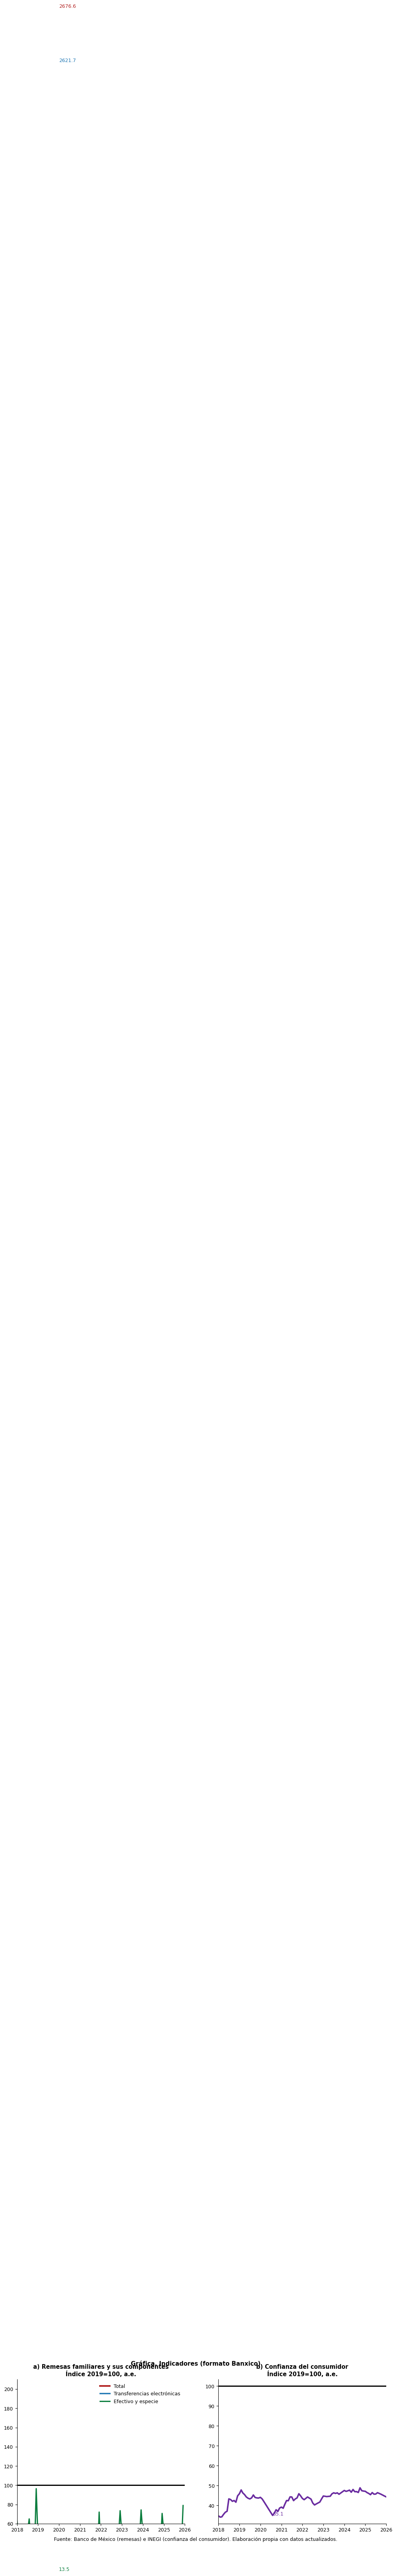

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata

# ============================================================
# CONFIG
# ============================================================
PATH_REMESAS = "raw/remesas.xlsx"
PATH_ICC     = "raw/Indicador_de_confianza_del_consumidor.xlsx"

START_DATE = "2018-01-01"
BASE_YEAR  = 2019

# --- límites Y TRUNCADOS para panel a)
YMIN_A = 60
YMAX_A = 210

# Colores Banxico
RED   = "#b22222"
BLUE  = "#1f77b4"
GREEN = "#0b7d3e"
PURP  = "#6a2ca0"
BLACK = "#000000"

# ============================================================
# HELPERS
# ============================================================
def _norm(s: str) -> str:
    s = str(s).strip().lower()
    s = "".join(c for c in unicodedata.normalize("NFD", s)
                if unicodedata.category(c) != "Mn")
    return s

MONTH_MAP = {
    "enero":1,"febrero":2,"marzo":3,"abril":4,"mayo":5,"junio":6,
    "julio":7,"agosto":8,"septiembre":9,"setiembre":9,
    "octubre":10,"noviembre":11,"diciembre":12,
    "ene":1,"feb":2,"mar":3,"abr":4,"may":5,"jun":6,
    "jul":7,"ago":8,"sep":9,"oct":10,"nov":11,"dic":12
}

# ------------------------------------------------------------
def style_banxico_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    ax.tick_params(labelsize=9)
    ax.axhline(100, color=BLACK, lw=2.2)

# ------------------------------------------------------------


# ------------------------------------------------------------
def annotate_minima(ax, df, cols, colors):
    w = df[(df["date"] >= "2020-01-01") &
           (df["date"] <= "2020-12-31")]

    mins = []
    for c,col in zip(cols,colors):
        i = w[c].idxmin()
        mins.append((w.loc[i,"date"], w.loc[i,c], col))

    x0 = min(mins, key=lambda t: t[0])[0]
    mins = sorted(mins, key=lambda t: t[1], reverse=True)

    for k,(x,y,col) in enumerate(mins):
        ax.text(x0, y - k*1.3, f"{y:.1f}",
                color=col, fontsize=9)

# ============================================================
# 1) REMESAS — lector Banxico
# ============================================================
def read_remesas(path):
    raw = pd.read_excel(path, header=None)

    def row(lbl):
        return raw.index[raw[0].astype(str).eq(lbl)][0]

    r_title = row("Título")
    r_unit  = row("Unidad")
    r_date  = row("Fecha")

    titles = raw.loc[r_title,1:]
    units  = raw.loc[r_unit,1:]
    codes  = raw.loc[r_date,1:]

    dat = raw.loc[r_date+1:,:]
    dat = dat.rename(columns={0:"date"})
    dat["date"] = pd.to_datetime(dat["date"])
    dat = dat.iloc[:,:len(codes)+1]
    dat.columns = ["date"] + list(codes)

    meta = pd.DataFrame({
        "code":codes.values,
        "title":titles.values,
        "unit":units.values
    })

    def pick(title):
        m = meta[(meta["title"]==title) &
                 (meta["unit"]=="Millones de Dólares")]
        code = m.iloc[0]["code"]
        return dat[["date",code]].rename(columns={code:title})

    out = pd.DataFrame({"date":dat["date"]})
    out = out.merge(pick("Remesas Familiares, Total"),on="date")
    out = out.merge(pick("Remesas Familiares, Efectivo y Especie"),on="date")
    out = out.merge(pick("Remesas Familiares, Transferencias Electrónicas"),on="date")

    return out.rename(columns={
        "Remesas Familiares, Total":"total",
        "Remesas Familiares, Efectivo y Especie":"efectivo",
        "Remesas Familiares, Transferencias Electrónicas":"transfer"
    })

# ============================================================
# 2) ICC — lector INEGI
# ============================================================
def read_icc(path):
    raw = pd.read_excel(path, sheet_name="Total", header=None)

    i0 = raw.index[raw[0].astype(str).eq("Periodo")][0]
    mat = raw.loc[i0+1:,[0,1]]
    mat.columns = ["Periodo","ICC"]

    mat["year"] = pd.to_numeric(mat["Periodo"], errors="coerce").ffill()
    mat["mon"]  = mat["Periodo"].map(_norm).map(MONTH_MAP)

    mat = mat.dropna()
    mat["date"] = pd.to_datetime(dict(
        year=mat["year"].astype(int),
        month=mat["mon"].astype(int),
        day=1))

    return mat[["date","ICC"]]

# ============================================================
# CARGA + REBASE + CORTE
# ============================================================
rem = read_remesas(PATH_REMESAS)
icc = read_icc(PATH_ICC)


rem = rem[rem["date"]>=START_DATE]
icc = icc[icc["date"]>=START_DATE]

x_min = pd.to_datetime(START_DATE)
x_max = max(rem["date"].max(), icc["date"].max())

# ============================================================
# FIGURA
# ============================================================
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12.2,4.8))

fig.suptitle("Gráfica. Indicadores (formato Banxico)",
             fontsize=11,fontweight="bold")

# -------- Panel a
ax1.plot(rem["date"], rem["total"], lw=3, color=RED, label="Total", zorder=3)
ax1.plot(rem["date"], rem["transfer"], lw=2.5, color=BLUE, label="Transferencias electrónicas")
ax1.plot(rem["date"], rem["efectivo"], lw=2.3, color=GREEN, label="Efectivo y especie")

ax1.set_ylim(YMIN_A, YMAX_A)

ax1.set_title("a) Remesas familiares y sus componentes\nÍndice 2019=100, a.e.",
              fontsize=10.5,fontweight="bold")

style_banxico_axis(ax1)
ax1.legend(frameon=False,fontsize=9)

annotate_minima(
    ax1, rem,
    ["total","transfer","efectivo"],
    [RED,BLUE,GREEN]
)

# -------- Panel b
ax2.plot(icc["date"], icc["ICC"], lw=2.8, color=PURP)
ax2.set_title("b) Confianza del consumidor\nÍndice 2019=100, a.e.",
              fontsize=10.5,fontweight="bold")

style_banxico_axis(ax2)

annotate_minima(
    ax2, icc,
    ["ICC"],
    [PURP]
)

# -------- EJE X
years = pd.date_range(x_min, x_max, freq="YS")
for ax in (ax1,ax2):
    ax.set_xlim(x_min,x_max)
    ax.set_xticks(years)
    ax.set_xticklabels([d.year for d in years])

# -------- Nota
fig.text(
    0.5,0.02,
    "Fuente: Banco de México (remesas) e INEGI (confianza del consumidor). "
    "Elaboración propia con datos actualizados.",
    ha="center",fontsize=9)

plt.tight_layout(rect=[0,0.05,1,0.93])
plt.show()


In [23]:
rem

,date,total,efectivo,transfer
276,2018-01-01,74.37742,201.949096,72.787177
277,2018-02-01,73.846834,128.705477,73.188936
278,2018-03-01,87.975769,141.142055,87.450064
279,2018-04-01,90.728948,110.104366,90.539859
280,2018-05-01,104.128895,124.125403,103.9536
...,...,...,...,...
367,2025-08-01,179.988407,115.30224,180.997451
368,2025-09-01,168.0568,98.675204,169.086096
369,2025-10-01,181.5218,131.320139,182.397528
370,2025-11-01,165.0952,108.366178,166.049034


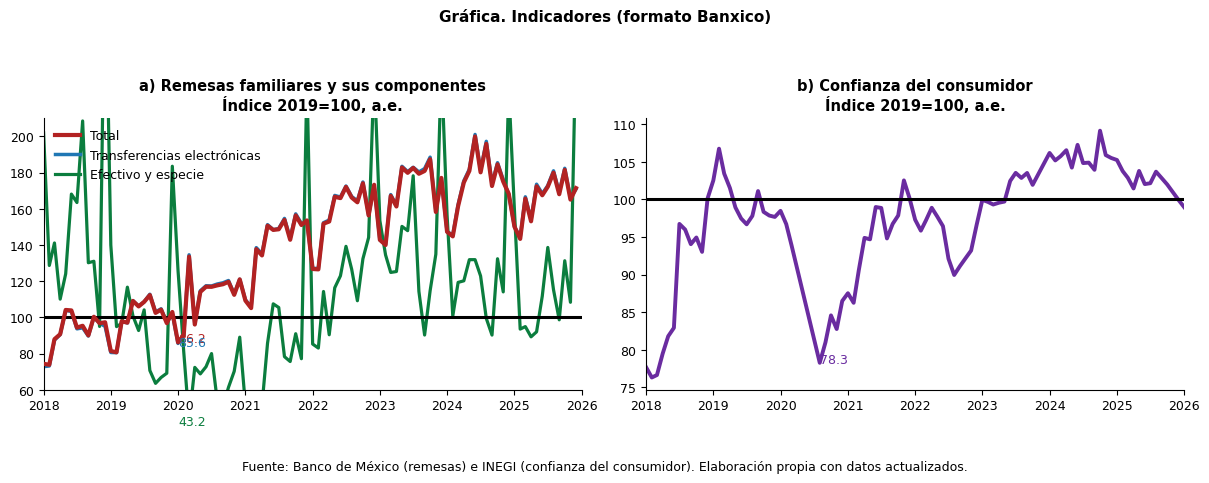

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata

# ============================================================
# CONFIG
# ============================================================
PATH_REMESAS = "raw/remesas.xlsx"
PATH_ICC     = "raw/Indicador_de_confianza_del_consumidor.xlsx"

START_DATE = "2018-01-01"
BASE_YEAR  = 2019

# --- límites Y TRUNCADOS para panel a)
YMIN_A = 60
YMAX_A = 210

# Colores Banxico
RED   = "#b22222"
BLUE  = "#1f77b4"
GREEN = "#0b7d3e"
PURP  = "#6a2ca0"
BLACK = "#000000"

# ============================================================
# HELPERS
# ============================================================
def _norm(s: str) -> str:
    s = str(s).strip().lower()
    s = "".join(c for c in unicodedata.normalize("NFD", s)
                if unicodedata.category(c) != "Mn")
    return s

MONTH_MAP = {
    "enero":1,"febrero":2,"marzo":3,"abril":4,"mayo":5,"junio":6,
    "julio":7,"agosto":8,"septiembre":9,"setiembre":9,
    "octubre":10,"noviembre":11,"diciembre":12,
    "ene":1,"feb":2,"mar":3,"abr":4,"may":5,"jun":6,
    "jul":7,"ago":8,"sep":9,"oct":10,"nov":11,"dic":12
}

# ------------------------------------------------------------
def style_banxico_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    ax.tick_params(labelsize=9)
    ax.axhline(100, color=BLACK, lw=2.2)

# ------------------------------------------------------------
def rebase_to_2019(df, cols):
    out = df.copy()
    base = out[out["date"].dt.year == BASE_YEAR]
    if base.empty:
        raise ValueError("No hay datos en 2019 para rebasar.")

    for c in cols:
        b = base[c].mean()
        out[c] = 100 * out[c] / b

    return out

# ------------------------------------------------------------
def annotate_minima(ax, df, cols, colors):
    w = df[(df["date"] >= "2020-01-01") &
           (df["date"] <= "2020-12-31")]

    mins = []
    for c,col in zip(cols,colors):
        i = w[c].idxmin()
        mins.append((w.loc[i,"date"], w.loc[i,c], col))

    x0 = min(mins, key=lambda t: t[0])[0]
    mins = sorted(mins, key=lambda t: t[1], reverse=True)

    for k,(x,y,col) in enumerate(mins):
        ax.text(x0, y - k*1.3, f"{y:.1f}",
                color=col, fontsize=9)

# ============================================================
# 1) REMESAS — lector Banxico
# ============================================================
def read_remesas(path):
    raw = pd.read_excel(path, header=None)

    def row(lbl):
        return raw.index[raw[0].astype(str).eq(lbl)][0]

    r_title = row("Título")
    r_unit  = row("Unidad")
    r_date  = row("Fecha")

    titles = raw.loc[r_title,1:]
    units  = raw.loc[r_unit,1:]
    codes  = raw.loc[r_date,1:]

    dat = raw.loc[r_date+1:,:]
    dat = dat.rename(columns={0:"date"})
    dat["date"] = pd.to_datetime(dat["date"])
    dat = dat.iloc[:,:len(codes)+1]
    dat.columns = ["date"] + list(codes)

    meta = pd.DataFrame({
        "code":codes.values,
        "title":titles.values,
        "unit":units.values
    })

    def pick(title):
        m = meta[(meta["title"]==title) &
                 (meta["unit"]=="Millones de Dólares")]
        code = m.iloc[0]["code"]
        return dat[["date",code]].rename(columns={code:title})

    out = pd.DataFrame({"date":dat["date"]})
    out = out.merge(pick("Remesas Familiares, Total"),on="date")
    out = out.merge(pick("Remesas Familiares, Efectivo y Especie"),on="date")
    out = out.merge(pick("Remesas Familiares, Transferencias Electrónicas"),on="date")

    return out.rename(columns={
        "Remesas Familiares, Total":"total",
        "Remesas Familiares, Efectivo y Especie":"efectivo",
        "Remesas Familiares, Transferencias Electrónicas":"transfer"
    })

# ============================================================
# 2) ICC — lector INEGI
# ============================================================
def read_icc(path):
    raw = pd.read_excel(path, sheet_name="Total", header=None)

    i0 = raw.index[raw[0].astype(str).eq("Periodo")][0]
    mat = raw.loc[i0+1:,[0,1]]
    mat.columns = ["Periodo","ICC"]

    mat["year"] = pd.to_numeric(mat["Periodo"], errors="coerce").ffill()
    mat["mon"]  = mat["Periodo"].map(_norm).map(MONTH_MAP)

    mat = mat.dropna()
    mat["date"] = pd.to_datetime(dict(
        year=mat["year"].astype(int),
        month=mat["mon"].astype(int),
        day=1))

    return mat[["date","ICC"]]

# ============================================================
# CARGA + REBASE + CORTE
# ============================================================
rem = read_remesas(PATH_REMESAS)
icc = read_icc(PATH_ICC)

rem = rebase_to_2019(rem, ["total","efectivo","transfer"])
icc = rebase_to_2019(icc, ["ICC"])

rem = rem[rem["date"]>=START_DATE]
icc = icc[icc["date"]>=START_DATE]

x_min = pd.to_datetime(START_DATE)
x_max = max(rem["date"].max(), icc["date"].max())

# ============================================================
# FIGURA
# ============================================================
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12.2,4.8))

fig.suptitle("Gráfica. Indicadores (formato Banxico)",
             fontsize=11,fontweight="bold")

# -------- Panel a
ax1.plot(rem["date"], rem["total"], lw=3, color=RED, label="Total", zorder=3)
ax1.plot(rem["date"], rem["transfer"], lw=2.5, color=BLUE, label="Transferencias electrónicas")
ax1.plot(rem["date"], rem["efectivo"], lw=2.3, color=GREEN, label="Efectivo y especie")

ax1.set_ylim(YMIN_A, YMAX_A)

ax1.set_title("a) Remesas familiares y sus componentes\nÍndice 2019=100, a.e.",
              fontsize=10.5,fontweight="bold")

style_banxico_axis(ax1)
ax1.legend(frameon=False,fontsize=9)

annotate_minima(
    ax1, rem,
    ["total","transfer","efectivo"],
    [RED,BLUE,GREEN]
)

# -------- Panel b
ax2.plot(icc["date"], icc["ICC"], lw=2.8, color=PURP)
ax2.set_title("b) Confianza del consumidor\nÍndice 2019=100, a.e.",
              fontsize=10.5,fontweight="bold")

style_banxico_axis(ax2)

annotate_minima(
    ax2, icc,
    ["ICC"],
    [PURP]
)

# -------- EJE X
years = pd.date_range(x_min, x_max, freq="YS")
for ax in (ax1,ax2):
    ax.set_xlim(x_min,x_max)
    ax.set_xticks(years)
    ax.set_xticklabels([d.year for d in years])

# -------- Nota
fig.text(
    0.5,0.02,
    "Fuente: Banco de México (remesas) e INEGI (confianza del consumidor). "
    "Elaboración propia con datos actualizados.",
    ha="center",fontsize=9)

plt.tight_layout(rect=[0,0.05,1,0.93])
plt.show()


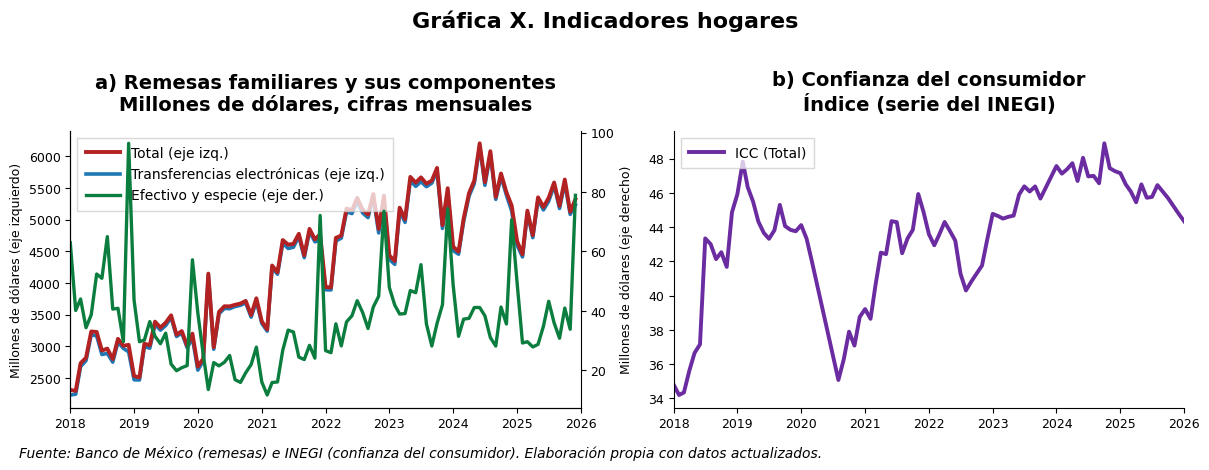

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata

# ============================================================
# CONFIG
# ============================================================
PATH_REMESAS = "raw/remesas.xlsx"
PATH_ICC     = "raw/Indicador_de_confianza_del_consumidor.xlsx"

START_DATE = "2018-01-01"

# Colores Banxico-like
RED   = "#b22222"  # Total
BLUE  = "#1f77b4"  # Transferencias
GREEN = "#0b7d3e"  # Efectivo y especie (eje derecho)
PURP  = "#6a2ca0"  # ICC
BLACK = "#000000"

# ============================================================
# HELPERS
# ============================================================
def _norm(s: str) -> str:
    s = str(s).strip().lower()
    s = "".join(
        c for c in unicodedata.normalize("NFD", s)
        if unicodedata.category(c) != "Mn"
    )
    return s

MONTH_MAP = {
    "enero":1,"febrero":2,"marzo":3,"abril":4,"mayo":5,"junio":6,
    "julio":7,"agosto":8,"septiembre":9,"setiembre":9,
    "octubre":10,"noviembre":11,"diciembre":12,
    "ene":1,"feb":2,"mar":3,"abr":4,"may":5,"jun":6,
    "jul":7,"ago":8,"sep":9,"oct":10,"nov":11,"dic":12
}

def style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    ax.tick_params(labelsize=9)

# ============================================================
# 1) REMESAS (Banxico): lee valores TAL CUAL del Excel
# ============================================================
def read_banxico_remesas_excel(path: str) -> pd.DataFrame:
    raw = pd.read_excel(path, sheet_name=0, header=None)

    def find_row(label):
        idx = raw.index[raw[0].astype(str).str.strip().eq(label)]
        if len(idx) == 0:
            raise ValueError(f"No encontré fila '{label}' en remesas.xlsx.")
        return int(idx[0])

    r_title = find_row("Título")
    r_unit  = find_row("Unidad")
    r_date  = find_row("Fecha")

    titles = raw.loc[r_title, 1:].tolist()
    units  = raw.loc[r_unit, 1:].tolist()
    codes  = raw.loc[r_date, 1:].tolist()

    dat = raw.loc[r_date+1:, :].copy()
    dat = dat.rename(columns={0: "date"})
    dat["date"] = pd.to_datetime(dat["date"], errors="coerce")
    dat = dat.dropna(subset=["date"])

    dat = dat.iloc[:, :len(codes)+1]
    dat.columns = ["date"] + codes

    meta = pd.DataFrame({"code": codes, "title": titles, "unit": units})
    meta["title"] = meta["title"].astype(str).str.strip()
    meta["unit"]  = meta["unit"].astype(str).str.strip()

    def get_series(title_exact: str, unit_exact: str = "Millones de Dólares"):
        m = meta[(meta["title"] == title_exact) & (meta["unit"] == unit_exact)]
        if m.empty:
            # fallback normalizado
            tt = _norm(title_exact)
            uu = _norm(unit_exact)
            m = meta[(meta["title"].map(_norm) == tt) & (meta["unit"].map(_norm) == uu)]
            if m.empty:
                raise ValueError(f"No encontré '{title_exact}' con unidad '{unit_exact}'.")
        code = m.iloc[0]["code"]
        s = dat[["date", code]].rename(columns={code: title_exact}).copy()
        s[title_exact] = pd.to_numeric(s[title_exact], errors="coerce")
        return s

    out = pd.DataFrame({"date": dat["date"]})

    out = out.merge(get_series("Remesas Familiares, Total"), on="date", how="left")
    out = out.merge(get_series("Remesas Familiares, Transferencias Electrónicas"), on="date", how="left")
    out = out.merge(get_series("Remesas Familiares, Efectivo y Especie"), on="date", how="left")

    out = out.rename(columns={
        "Remesas Familiares, Total": "total",
        "Remesas Familiares, Transferencias Electrónicas": "transfer_elec",
        "Remesas Familiares, Efectivo y Especie": "efectivo_especie",
    })

    out = out.sort_values("date").reset_index(drop=True)
    return out

# ============================================================
# 2) ICC (INEGI): lee la hoja "Total" (matriz año/mes)
# ============================================================
def read_icc_inegi_excel(path: str, sheet_name="Total") -> pd.DataFrame:
    raw = pd.read_excel(path, sheet_name=sheet_name, header=None)

    idx = raw.index[raw[0].astype(str).str.strip().eq("Periodo")]
    if len(idx) == 0:
        raise ValueError("No encontré la fila 'Periodo' en el ICC.")
    i0 = int(idx[0])

    mat = raw.loc[i0+1:, [0, 1]].copy()
    mat.columns = ["Periodo", "ICC"]

    mat["Periodo"] = mat["Periodo"].astype(str).str.strip()
    mat["year"] = pd.to_numeric(mat["Periodo"], errors="coerce").ffill()
    mat["mon_key"] = mat["Periodo"].map(_norm)
    mat["month"] = mat["mon_key"].map(MONTH_MAP)

    mat["ICC"] = pd.to_numeric(mat["ICC"], errors="coerce")
    mat = mat[mat["month"].notna() & mat["ICC"].notna() & mat["year"].notna()].copy()

    mat["date"] = pd.to_datetime(dict(
        year=mat["year"].astype(int),
        month=mat["month"].astype(int),
        day=1
    ))

    return mat[["date", "ICC"]].sort_values("date").reset_index(drop=True)

# ============================================================
# 3) CARGA + RECORTE 2018+
# ============================================================
start = pd.to_datetime(START_DATE)

rem = read_banxico_remesas_excel(PATH_REMESAS)
icc = read_icc_inegi_excel(PATH_ICC, sheet_name="Total")

rem = rem[rem["date"] >= start].copy()
icc = icc[icc["date"] >= start].copy()

x_min = start
x_max = max(rem["date"].max(), icc["date"].max())

# ============================================================
# 4) FIGURA 2 PANELES (Banxico-style) + DOBLE EJE EN (a)
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.2, 4.9))

fig.suptitle("Gráfica X. Indicadores hogares", fontsize=16, fontweight="bold", y=0.94)

# ---------------- Panel (a): Remesas con doble eje ----------------
ax1b = ax1.twinx()  # eje derecho

# líneas
l1, = ax1.plot(rem["date"], rem["total"], color=RED, lw=2.8, label="Total (eje izq.)", zorder=3)
l2, = ax1.plot(rem["date"], rem["transfer_elec"], color=BLUE, lw=2.6, label="Transferencias electrónicas (eje izq.)", zorder=2)
l3, = ax1b.plot(rem["date"], rem["efectivo_especie"], color=GREEN, lw=2.4, label="Efectivo y especie (eje der.)", zorder=1)

ax1.set_title("a) Remesas familiares y sus componentes\nMillones de dólares, cifras mensuales",
              fontsize=14, fontweight="bold", pad=15)

# estilo ejes
style_axis(ax1)
ax1b.spines["top"].set_visible(False)   # para que no se vea borde superior
ax1b.grid(False)
ax1b.tick_params(labelsize=9)

# Etiquetas de ejes (clarísimo qué corresponde a qué)
ax1.set_ylabel("Millones de dólares (eje izquierdo)", color=BLACK, fontsize=9)
ax1b.set_ylabel("Millones de dólares (eje derecho)", color=BLACK, fontsize=9)
ax1b.tick_params(axis="y")

# límites x + ticks anuales
years = pd.date_range(x_min, x_max, freq="YS")
ax1.set_xlim(x_min, x_max)
ax1.set_xticks(years)
ax1.set_xticklabels([d.year for d in years], fontsize=9)

# Leyenda combinada (incluye eje)
handles = [l1, l2, l3]
labels = [h.get_label() for h in handles]
ax1.legend(
    handles=[l1, l2, l3], 
    loc="upper left",
    frameon=True,
    fancybox=False,
    framealpha=.75,
    borderpad=0.6,
    handlelength=2.5,
    handletextpad=0.8,
    columnspacing=1.2)

# ---------------- Panel (b): ICC ----------------
ax2.plot(icc["date"], icc["ICC"], color=PURP, lw=2.8, label="ICC (Total)")

ax2.set_title("b) Confianza del consumidor\nÍndice (serie del INEGI)",
              fontsize=14, fontweight="bold", pad=15)

style_axis(ax2)
ax2.legend(
    loc="upper left",
    frameon=True,
    fancybox=False,
    framealpha=.75,
    borderpad=0.6,
    handlelength=2.5,
    handletextpad=0.8,
    columnspacing=1.2)

ax2.set_xlim(x_min, x_max)
ax2.set_xticks(years)
ax2.set_xticklabels([d.year for d in years], fontsize=9)

# ---------------- Nota ----------------
fig.text(
    0.02, 0.02,
    "Fuente: Banco de México (remesas) e INEGI (confianza del consumidor). Elaboración propia con datos actualizados.",
    ha="left", va="bottom", fontsize=10, style="italic"
)

plt.tight_layout(rect=[0, 0.05, 1, 0.92])
plt.show()


In [25]:
handles

In [26]:
labels

['Total (eje izq.)',
 'Transferencias electrónicas (eje izq.)',
 'Efectivo y especie (eje der.)']